# Backtest 001 — Bollinger Squeeze + 2-State HMM Regime (Position Sizing)

**Goal:** Walk-forward 2-state HMM (Risk-On / Risk-Off, weekly retraining) used as a
position-sizing overlay on the Bollinger Squeeze + DeMarker strategy.

| Regime   | Budget fraction |
|----------|-----------------|
| Risk-On  | 100%            |
| Risk-Off | 25%             |


In [18]:
# ── dependencies ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns

import vectorbt as vbt
import numba as nb
from numba import njit, prange

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

# path for custom indicators
sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.vwap import avwap_func_nb
from backend.app.services.indicators.trailing_sl import atr_trailing_nb

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [19]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'

df_raw = load_stocks()

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

# drop symbols with >20% missing
valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
open_  = open_[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

# benchmark series for HMM features
if BENCHMARK in close.columns:
    bm_close  = close[BENCHMARK]
    bm_volume = volume[BENCHMARK]
else:
    bm_close  = close.mean(axis=1)
    bm_volume = volume.mean(axis=1)
    print(f'BENCHMARK {BENCHMARK!r} not found — using equal-weight index')

print(f'Symbols  : {len(valid_syms)}')
print(f'Benchmark: {BENCHMARK}  rows={len(bm_close)}')


Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2501, 990)  |  2016-06-20 → 2026-06-19
Symbols  : 198
Benchmark: VNINDEX  rows=2501


## 2. Walk-Forward HMM Regime (Zero Lookahead)

**Algorithm:**
```
burn_in = 252 trading days (~1 year) — minimum data to train initial model
retrain_freq = monthly (every ~21 trading days)

For each retraining date T (starting after burn_in):
    1. Build feature matrix X[0:T] (log-ret, vol, momentum, vol-ratio)
    2. Fit GaussianHMM on X[0:T]
    3. current_state = model.predict(X[0:T])[-1]   ← regime AT date T
    4. Fill regime[T+1 : T+retrain_freq] = label(current_state)
```

The regime array is shifted forward so it never overlaps the training window.

In [20]:
# ── feature engineering on benchmark ─────────────────────────────────────────
W = 20

feat_bm = pd.DataFrame(index=bm_close.index)
feat_bm['log_ret']    = np.log(bm_close / bm_close.shift(1))
feat_bm['volatility'] = feat_bm['log_ret'].rolling(W).std()
feat_bm['momentum']   = np.log(bm_close / bm_close.shift(W))
feat_bm['vol_ratio']  = bm_volume / bm_volume.rolling(W).mean()
feat_bm = feat_bm.dropna()

FEATURE_COLS = ['log_ret', 'volatility', 'momentum', 'vol_ratio']
print(f'Feature matrix: {feat_bm.shape}')

Feature matrix: (2481, 4)


In [21]:
# ── HMM config ──────────────────────────────────────────────────────────────
BURN_IN_DAYS  = 252   # minimum training window
RANDOM_SEED   = 42


In [22]:
def build_wf_regime(
    feat_df,
    feature_cols,
    n_components=3,
    burn_in=252,
    retrain_every=21,
    random_seed=42,
):
    """
    Walk-forward HMM regime labelling (zero lookahead).

    Returns a pd.Series of 'Bull' / 'Neutral' / 'Bear' (or 'Risk-On' / 'Risk-Off'
    for 2-state) indexed to feat_df, with NaN before the first prediction.
    """
    from hmmlearn.hmm import GaussianHMM
    from sklearn.preprocessing import StandardScaler

    feat_arr  = feat_df[feature_cols].values
    dates     = feat_df.index.tolist()
    n_total   = len(dates)
    wf_label  = pd.Series('Unknown', index=feat_df.index, name='regime')

    retrain_indices = list(range(burn_in - 1, n_total - 1, retrain_every))

    for ri, train_end_idx in enumerate(retrain_indices):
        X_train  = feat_arr[:train_end_idx + 1]
        scaler   = StandardScaler()
        X_scaled = scaler.fit_transform(X_train)

        model = GaussianHMM(
            n_components=n_components,
            covariance_type='full',
            n_iter=500,
            random_state=random_seed,
            tol=1e-4,
            verbose=False,
        )
        model.fit(X_scaled)
        states_train = model.predict(X_scaled)

        mean_rets = {
            s: feat_arr[:train_end_idx + 1, 0][states_train == s].mean()
            for s in range(n_components)
        }
        ranked    = sorted(mean_rets, key=mean_rets.get)
        if n_components == 2:
            label_map = {ranked[0]: 'Bear', ranked[1]: 'Bull'}
        else:
            label_map = {ranked[0]: 'Bear', ranked[1]: 'Neutral', ranked[2]: 'Bull'}

        current_label = label_map[states_train[-1]]
        next_idx      = retrain_indices[ri + 1] if ri + 1 < len(retrain_indices) else n_total
        wf_label.iloc[train_end_idx + 1:next_idx] = current_label

    return wf_label

print('build_wf_regime defined')


build_wf_regime defined


## 3. Bollinger Squeeze + DeMarker Strategy (Baseline)

Exact same indicators and parameters as `backtest_001.ipynb`.

In [23]:
# ── Bollinger Squeeze + DeMarker indicator (Numba) ────────────────────────────
import numba as nb

@nb.njit(cache=True)
def bollinger_squeeze_demarker_nb(
    high_arr, low_arr, close_arr,
    demarker_period: int = 11,
    keltner_period:  int = 16,
    bb_period:       int = 15,
    bb_deviation:  float = 2.3,
    keltner_factor:float = 2.2,
):
    n = len(close_arr)
    # outputs
    squeeze_on = np.zeros(n, dtype=nb.boolean)
    direction  = np.zeros(n, dtype=nb.int64)

    for i in range(max(demarker_period, keltner_period, bb_period), n):
        # --- DeMarker ---
        dm_sum_high = 0.0
        dm_sum_low  = 0.0
        for j in range(i - demarker_period + 1, i + 1):
            dh = max(high_arr[j] - high_arr[j-1], 0.0)
            dl = max(low_arr[j-1]  - low_arr[j],   0.0)
            dm_sum_high += dh
            dm_sum_low  += dl
        denom = dm_sum_high + dm_sum_low
        dem   = dm_sum_high / denom if denom != 0.0 else 0.5

        # --- Bollinger Bands ---
        bb_slice = close_arr[i - bb_period + 1 : i + 1]
        bb_mean  = bb_slice.mean()
        bb_std   = bb_slice.std()
        bb_upper = bb_mean + bb_deviation * bb_std
        bb_lower = bb_mean - bb_deviation * bb_std
        bb_width = bb_upper - bb_lower

        # --- Keltner Channel (EMA approximation via SMA) ---
        kc_slice = close_arr[i - keltner_period + 1 : i + 1]
        kc_mean  = kc_slice.mean()
        atr_sum  = 0.0
        for j in range(i - keltner_period + 1, i + 1):
            atr_sum += max(high_arr[j], close_arr[j-1]) - min(low_arr[j], close_arr[j-1])
        atr_avg  = atr_sum / keltner_period
        kc_width = 2.0 * keltner_factor * atr_avg

        squeeze_on[i] = bb_width < kc_width
        direction[i]  = 1 if dem > 0.5 else -1

    return squeeze_on, direction

print('Numba indicator compiled')

Numba indicator compiled


In [24]:
# ── parameters (from backtest_001 optimised run) ──────────────────────────────
DEMARKER_PERIOD = 11
KELTNER_PERIOD  = 16
BB_PERIOD       = 15
BB_DEVIATION    = 2.3
KELTNER_FACTOR  = 2.2
ATR_PERIOD      = 10
ATR_MULTIPLIER  = 1.8
RVOL_PERIOD     = 10
RVOL_MIN        = 1.25
SL_STOP         = 0.10

# ── compute signals ───────────────────────────────────────────────────────────
squeeze_on_dict  = {}
direction_dict   = {}

for sym in valid_syms:
    h = high[sym].values
    l = low[sym].values
    c = close[sym].values
    sq, dr = bollinger_squeeze_demarker_nb(
        h, l, c,
        demarker_period=DEMARKER_PERIOD,
        keltner_period=KELTNER_PERIOD,
        bb_period=BB_PERIOD,
        bb_deviation=BB_DEVIATION,
        keltner_factor=KELTNER_FACTOR,
    )
    squeeze_on_dict[sym] = sq
    direction_dict[sym]  = dr

squeeze_on_df = pd.DataFrame(squeeze_on_dict, index=close.index)
direction_df  = pd.DataFrame(direction_dict,  index=close.index)

# RVOL (volume relative to prior N-day average, using prior bar to avoid lookahead)
vol_ma_prior = volume.shift(1).rolling(RVOL_PERIOD, min_periods=RVOL_PERIOD).mean()
rvol = volume / vol_ma_prior

# ATR trailing stop
atr_indicator = vbt.IndicatorFactory.from_talib('ATR').run(
    high, low, close, timeperiod=ATR_PERIOD
)
# shift ATR by 1 to use prior-bar ATR (no lookahead)
atr_scope = atr_indicator.real.shift(1)

ATRTrailing = vbt.IndicatorFactory(
    input_names=['close', 'atr'],
    param_names=['atr_multiplier'],
    output_names=['atr_trailing'],
).from_apply_func(atr_trailing_nb)

atr_sl = ATRTrailing.run(close, atr_scope, atr_multiplier=ATR_MULTIPLIER)

print('Signals computed')

Signals computed


In [25]:
# ── entry & exit signals ──────────────────────────────────────────────────────
# Entry: squeeze JUST turned off (was on yesterday, off today) AND bullish AND volume confirms
squeeze_released = squeeze_on_df.shift(1).fillna(False) & ~squeeze_on_df
bullish          = direction_df == 1
# vol_ok           = rvol >= RVOL_MIN

entries_base = squeeze_released & bullish

# Exit: price crosses below ATR trailing stop
exits = close.vbt.crossed_below(atr_sl.atr_trailing)

print(f'Total entry signals (baseline): {entries_base.sum().sum():,}')

Total entry signals (baseline): 9,558


In [26]:
def broadcast_mask(series_mask, columns):
    """Broadcast a boolean Series (dates,) to a DataFrame (dates × symbols)."""
    return pd.DataFrame(
        np.tile(series_mask.values.reshape(-1, 1), (1, len(columns))),
        index=series_mask.index, columns=columns,
    ).astype(bool)


In [27]:
INIT_CASH = 100
SL_STOP   = 0.10

COMMON_KWARGS = dict(
    freq        = '1d',
    group_by    = False,
    cash_sharing= False,
    sl_stop     = SL_STOP,
    init_cash   = INIT_CASH,
)

print('Running backtest — Baseline …')
pf_base = vbt.Portfolio.from_signals(
    close=close, entries=entries_base, exits=exits, **COMMON_KWARGS
)
print(f'Baseline Sharpe: {pf_base.sharpe_ratio().mean():.3f}')


Running backtest — Baseline …
Baseline Sharpe: 0.481


In [28]:
def portfolio_summary(pf, name):
    """Aggregate stats across all symbols."""
    sharpe    = pf.sharpe_ratio()
    sortino   = pf.sortino_ratio()
    total_ret = pf.total_return()
    max_dd    = pf.max_drawdown()
    n_trades  = pf.trades.count()
    win_rate  = pf.trades.win_rate()
    return pd.Series({
        'Portfolio':       name,
        'Sharpe (mean)':   sharpe.mean().round(3),
        'Sharpe (median)': sharpe.median().round(3),
        'Sharpe > 1.0':    f"{(sharpe > 1.0).sum()}/{len(sharpe)}",
        'Sortino (mean)':  sortino.mean().round(3),
        'Total Ret (mean)':f"{total_ret.mean():.1%}",
        'Max DD (mean)':   f"{max_dd.mean():.1%}",
        'Win Rate':        f"{win_rate.mean():.1%}",
    })


In [29]:
def full_stats(pf, name):
    s = pf.sharpe_ratio()
    return pd.Series({
        'Name':             name,
        'Sharpe mean':      s.mean().round(3),
        'Sharpe median':    s.median().round(3),
        'Sharpe std':       s.std().round(3),
        'Sharpe > 0':       f"{(s > 0).sum()}/{len(s)}",
        'Sharpe > 1':       f"{(s > 1).sum()}/{len(s)}",
        'Sortino mean':     pf.sortino_ratio().mean().round(3),
        'Calmar mean':      pf.calmar_ratio().mean().round(3),
        'Total Ret mean':   f"{pf.total_return().mean():.1%}",
        'Total Ret median': f"{pf.total_return().median():.1%}",
        'Max DD mean':      f"{pf.max_drawdown().mean():.1%}",
        'Max DD worst':     f"{pf.max_drawdown().min():.1%}",
        'N Trades':         int(pf.trades.count().sum()),
        'Avg Trade Ret':    f"{pd.Series(pf.trades.returns.mean()).mean():.2%}",
        'Win Rate':         f"{pf.trades.win_rate().mean():.1%}",
        'Profit Factor':    pf.trades.profit_factor().mean().round(3),
    })


## 3. 2-State HMM Regime + Position Sizing

- `n_components=2` — Risk-On / Risk-Off
- `retrain_every=5` (weekly) — ~5-day regime lag
- Position sizing: Risk-On = 100%, Risk-Off = 25% of budget


In [30]:
# ── walk-forward 2-state HMM, weekly retraining ───────────────────────────────
print('Running 2-state walk-forward HMM (weekly retraining) …')
regime_2state = build_wf_regime(
    feat_bm,
    FEATURE_COLS,
    n_components  = 2,
    burn_in       = BURN_IN_DAYS,
    retrain_every = 5,
    random_seed   = RANDOM_SEED,
)
print('Done.')

# Map labels: Bull→Risk-On, Bear→Risk-Off, Neutral→Risk-On (only 2 states so Neutral absent)
regime_2state = regime_2state.replace({'Bull': 'Risk-On', 'Neutral': 'Risk-On', 'Bear': 'Risk-Off'})
regime_2_aligned = regime_2state.reindex(close.index)

print('\nRegime distribution:')
print(regime_2state.value_counts())


Running 2-state walk-forward HMM (weekly retraining) …


Model is not converging.  Current: -3202.0188847110157 is not greater than -3202.018883822728. Delta is -8.88287559064338e-07
Model is not converging.  Current: -3248.6674028620932 is not greater than -3248.6674015959534. Delta is -1.2661398614000063e-06


Done.

Regime distribution:
regime
Risk-On     940
Risk-Off    844
Unknown     697
Name: count, dtype: int64


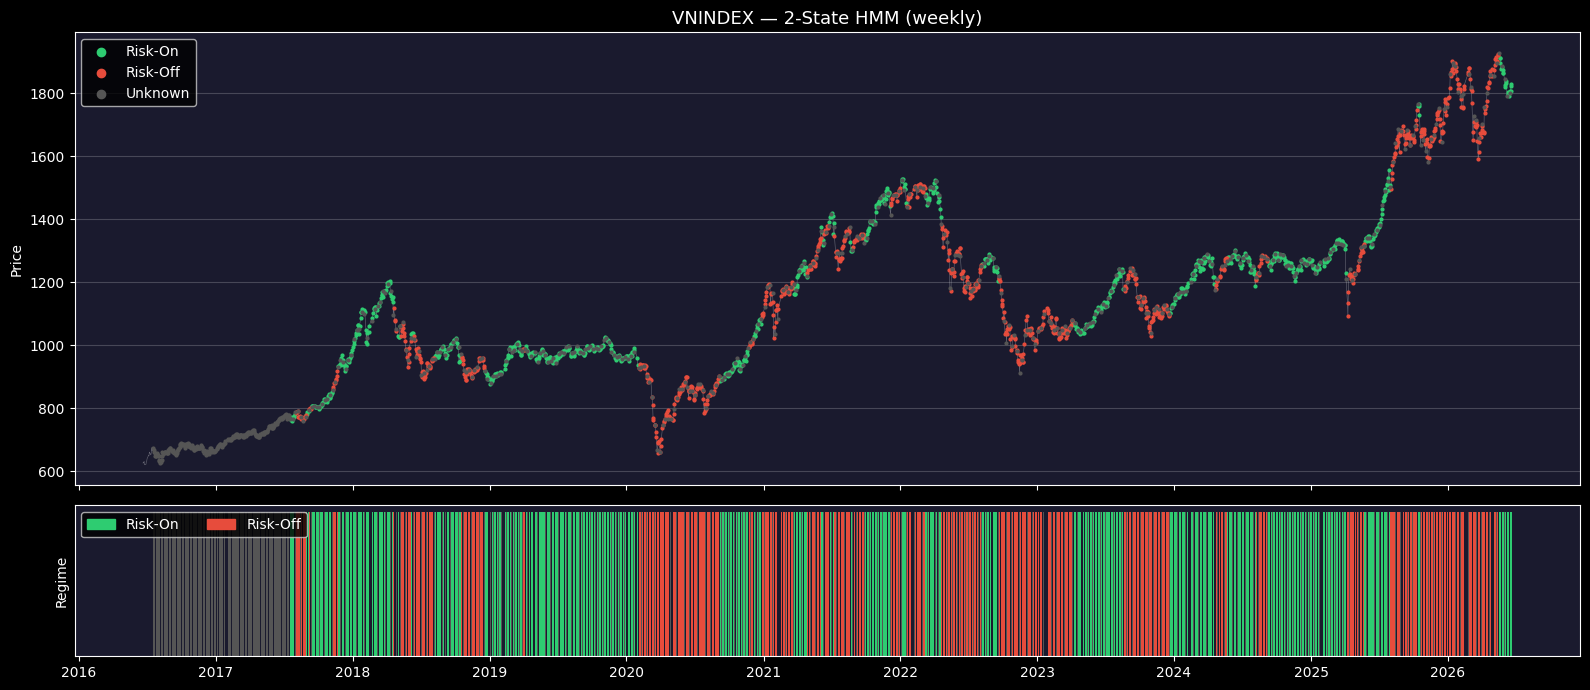

In [31]:
COLOR2 = {'Risk-On': '#2ecc71', 'Risk-Off': '#e74c3c', 'Unknown': '#555555'}

fig, axes = plt.subplots(2, 1, figsize=(16, 7),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax = axes[0]; ax.set_facecolor('#1a1a2e')
common = bm_close.index.intersection(regime_2state.index)
for lbl, col in COLOR2.items():
    mask = regime_2state.reindex(common) == lbl
    ax.scatter(common[mask], bm_close.reindex(common)[mask], s=4, c=col, label=lbl, zorder=3)
ax.plot(bm_close.index, bm_close.values, color='white', lw=0.4, alpha=0.35)
ax.set_ylabel('Price'); ax.set_title(f'{BENCHMARK} — 2-State HMM (weekly)', fontsize=13)
ax.legend(loc='upper left', markerscale=3); ax.yaxis.grid(True, alpha=0.2)

ax2 = axes[1]; ax2.set_facecolor('#1a1a2e')
c2 = [COLOR2.get(r, '#555') for r in regime_2state.reindex(common)]
ax2.bar(common, np.ones(len(common)), color=c2, width=1.5); ax2.set_yticks([])
ax2.set_ylabel('Regime')
patches2 = [mpatches.Patch(color=c, label=l) for l, c in COLOR2.items() if l != 'Unknown']
ax2.legend(handles=patches2, loc='upper left', ncol=2)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


In [32]:
# ── 2-state position sizing ─────────────────────────────────────────────────
SIZING_2STATE = {'Risk-On': 1.0, 'Risk-Off': 0.5, 'Unknown': 1.0}
size_frac_2    = regime_2_aligned.map(SIZING_2STATE).fillna(1.0)
size_frac_2_df = pd.DataFrame(
    np.tile(size_frac_2.values.reshape(-1, 1), (1, len(valid_syms))),
    index=size_frac_2.index, columns=valid_syms,
)
share_size_2_df = (size_frac_2_df * INIT_CASH / close).fillna(0)
share_size_2_df = share_size_2_df.replace([np.inf, -np.inf], 0)

print('Running 2-state position sizing backtest …')
pf_b2 = vbt.Portfolio.from_signals(
    close=close, entries=entries_base, exits=exits,
    size=share_size_2_df,
    freq='1d', group_by=False, cash_sharing=False,
    sl_stop=SL_STOP, init_cash=INIT_CASH,
)
print('Done.')
s_base = pf_base.sharpe_ratio().mean()
s_b2   = pf_b2.sharpe_ratio().mean()
print(f'Baseline Sharpe : {s_base:.3f}')
print(f'B2 pos sizing   : {s_b2:.3f}  ({s_b2 - s_base:+.3f} vs baseline)')


Running 2-state position sizing backtest …
Done.
Baseline Sharpe : 0.481
B2 pos sizing   : 0.526  (+0.045 vs baseline)


In [33]:
# ── summary comparison ───────────────────────────────────────────────────────
summary = pd.DataFrame([
    portfolio_summary(pf_base, 'Baseline'),
    portfolio_summary(pf_b2,   '2-State Pos Sizing'),
]).set_index('Portfolio')
display(summary)

# ── detailed stats ───────────────────────────────────────────────────────────
detail = pd.DataFrame([
    full_stats(pf_base, 'Baseline'),
    full_stats(pf_b2,   '2-State Pos Sizing'),
]).set_index('Name')
display(detail.T)


,Sharpe (mean),Sharpe (median),Sharpe > 1.0,Sortino (mean),Total Ret (mean),Max DD (mean),Win Rate
Portfolio,,,,,,,
Baseline,0.481,0.458,17/198,0.773,140.5%,-37.9%,41.2%
2-State Pos Sizing,0.526,0.504,26/198,0.877,72.8%,-28.2%,41.2%


Name,Baseline,2-State Pos Sizing
Sharpe mean,0.481,0.526
Sharpe median,0.458,0.504
Sharpe std,0.39,0.399
Sharpe > 0,178/198,180/198
Sharpe > 1,17/198,26/198
Sortino mean,0.773,0.877
Calmar mean,0.311,0.348
Total Ret mean,140.5%,72.8%
Total Ret median,66.0%,56.5%
Max DD mean,-37.9%,-28.2%


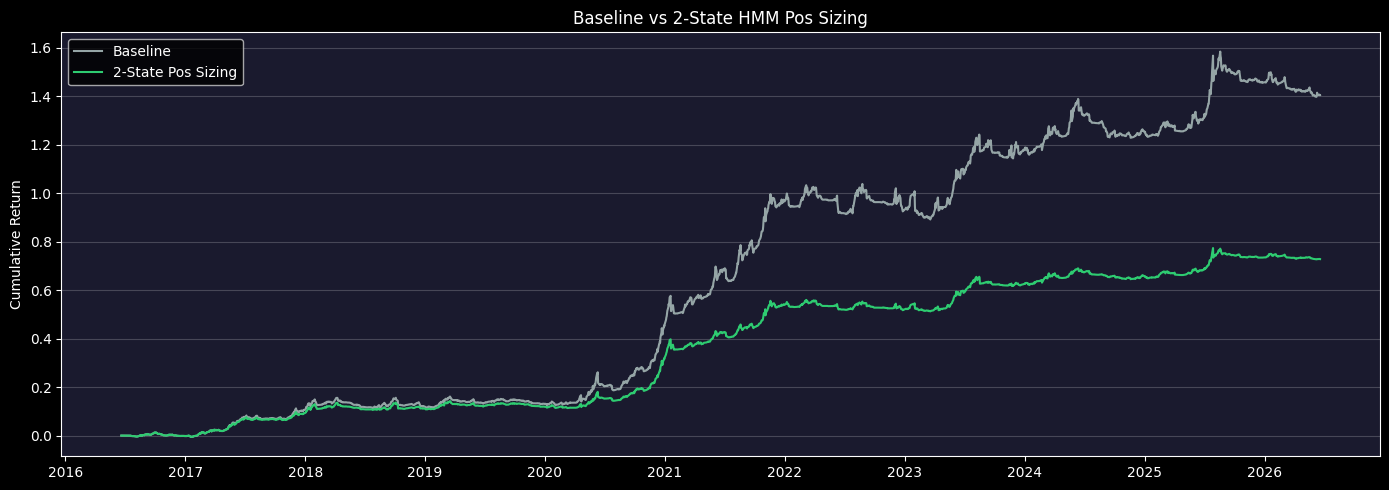

In [34]:
portfolios = [
    (pf_base, 'Baseline',          '#95a5a6'),
    (pf_b2,   '2-State Pos Sizing','#2ecc71'),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('#1a1a2e')
for pf, name, col in portfolios:
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=name, lw=1.5, color=col)
ax.set_title('Baseline vs 2-State HMM Pos Sizing')
ax.set_ylabel('Cumulative Return')
ax.legend(); ax.yaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()
